<a href="https://colab.research.google.com/github/hassanatif992-hash/urdu-ocr-codesaviours-si26-MuhammadHassaan/blob/main/SI26_Week3_MuhammadHassaan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 — Expand Dataset and Build Data Loader

**Name:** Muhammad Hassaan  
**Batch:** SI-26  
**Project:** Urdu OCR  
**Organisation:** Code Saviours  

## Week 3 Objective

The objective of Week 3 is to expand the Urdu OCR dataset to more than 200 images, update labels.csv, preprocess all new images, and prepare a PyTorch Dataset class for model training.

In [ ]:
!pip install -q pandas pillow opencv-python-headless

import os
import glob
import shutil
import zipfile
import pandas as pd
import cv2
from PIL import Image

print("Libraries installed and imported successfully!")

Libraries installed and imported successfully!


In [ ]:
import os
import shutil

source_path = "/week1_project.zip"
destination_path = "/content/week1_project.zip"

if os.path.exists(source_path):
    os.makedirs("/content", exist_ok=True)
    shutil.move(source_path, destination_path)
    print("ZIP moved successfully to /content!")
elif os.path.exists(destination_path):
    print("ZIP is already inside /content.")
else:
    print("ZIP file was not found.")

ZIP moved successfully to /content!


In [ ]:
import zipfile
import os
import shutil

zip_path = "/content/week1_project.zip"
extract_folder = "/content/week1_project"

if not os.path.exists(zip_path):
    print("ERROR: ZIP file was not found.")
else:
    if os.path.exists(extract_folder):
        shutil.rmtree(extract_folder)

    with zipfile.ZipFile(zip_path, "r") as zip_file:
        zip_file.extractall(extract_folder)

    print("Old project extracted successfully!")

Old project extracted successfully!


In [ ]:
data_candidates = glob.glob(
    "/content/week1_project/**/data",
    recursive=True
)

data_candidates = [
    path for path in data_candidates
    if os.path.isdir(path)
]

print("Data folders found:", data_candidates)

if not data_candidates:
    print("ERROR: No data folder was found inside the ZIP.")
else:
    source_data = data_candidates[0]
    destination_data = "/content/data"

    if os.path.exists(destination_data):
        shutil.rmtree(destination_data)

    shutil.copytree(source_data, destination_data)

    print("Old data folder restored successfully!")
    print("Source:", source_data)
    print("Destination:", destination_data)

Data folders found: ['/content/week1_project/urdu-ocr-codesaviours-si26-MuhammadHassaan-main/data']
Old data folder restored successfully!
Source: /content/week1_project/urdu-ocr-codesaviours-si26-MuhammadHassaan-main/data
Destination: /content/data


In [ ]:
os.makedirs("/content/data", exist_ok=True)

labels_destination = "/content/data/labels.csv"

if os.path.exists(labels_destination):
    print("labels.csv already exists inside data folder.")
else:
    labels_candidates = glob.glob(
        "/content/week1_project/**/labels.csv",
        recursive=True
    )

    print("labels.csv files found:", labels_candidates)

    if labels_candidates:
        shutil.copy2(
            labels_candidates[0],
            labels_destination
        )
        print("labels.csv copied into /content/data/")
    else:
        print("ERROR: labels.csv was not found.")

labels.csv files found: ['/content/week1_project/urdu-ocr-codesaviours-si26-MuhammadHassaan-main/labels.csv']
labels.csv copied into /content/data/


In [ ]:
folders = [
    "/content/data/raw/books",
    "/content/data/raw/newspaper",
    "/content/data/raw/signboards",
    "/content/data/raw/synthetic",
    "/content/data/raw/other",
    "/content/data/processed"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Week 3 folder structure is ready!")

Week 3 folder structure is ready!


In [ ]:
category_folders = {
    "Books": "/content/data/raw/books",
    "Newspaper": "/content/data/raw/newspaper",
    "Signboards": "/content/data/raw/signboards",
    "Synthetic": "/content/data/raw/synthetic",
    "Other": "/content/data/raw/other"
}

valid_extensions = (".png", ".jpg", ".jpeg")

old_total_images = 0

for category, folder in category_folders.items():
    count = 0

    for root, directories, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(valid_extensions):
                count += 1

    print(f"{category}: {count} images")
    old_total_images += count

print("\nTotal existing images:", old_total_images)

labels_path = "/content/data/labels.csv"

if os.path.exists(labels_path):
    old_labels_df = pd.read_csv(labels_path)
    print("Total existing labels:", len(old_labels_df))
else:
    print("ERROR: labels.csv was not found.")

Books: 22 images
Newspaper: 21 images
Signboards: 18 images
Synthetic: 20 images
Other: 21 images

Total existing images: 102
Total existing labels: 102


In [ ]:
import os
import shutil

source_path = "/Week 3 day 1 new.zip"
destination_path = "/content/week3_day1_new.zip"

if os.path.exists(source_path):
    shutil.move(source_path, destination_path)
    print("ZIP moved and renamed successfully!")
elif os.path.exists(destination_path):
    print("ZIP is already inside /content.")
else:
    print("ZIP file was not found. Check the exact filename.")

ZIP moved and renamed successfully!


In [ ]:
import os
import shutil
import zipfile

new_zip_path = "/content/week3_day1_new.zip"
new_extract_folder = "/content/day1_new"

if not os.path.exists(new_zip_path):
    print("ERROR: week3_day1_new.zip was not found.")
else:
    if os.path.exists(new_extract_folder):
        shutil.rmtree(new_extract_folder)

    with zipfile.ZipFile(new_zip_path, "r") as zip_file:
        zip_file.extractall(new_extract_folder)

    print("Day 1 images extracted successfully!")

Day 1 images extracted successfully!


In [ ]:
import os

for root, folders, files in os.walk("/content/day1_new"):
    print(root, "-", len(files), "files")

/content/day1_new - 0 files
/content/day1_new/Week 3 day 1 new - 0 files
/content/day1_new/Week 3 day 1 new/synthetics - 5 files
/content/day1_new/Week 3 day 1 new/Newspaper - 5 files
/content/day1_new/Week 3 day 1 new/Others - 5 files
/content/day1_new/Week 3 day 1 new/Book - 5 files
/content/day1_new/Week 3 day 1 new/Signboards - 5 files


In [ ]:
import os
import glob
import shutil

# Possible folder names inside your ZIP
folder_aliases = {
    "books": ["books", "book", "Books", "Book"],
    "newspaper": ["newspaper", "newspapers", "Newspaper", "Newspapers"],
    "signboards": ["signboards", "signboard", "Signboards", "Signboard"],
    "synthetic": ["synthetic", "synthetics", "Synthetic", "Synthetics"],
    "other": ["other", "others", "Other", "Others"]
}

destination_folders = {
    "books": "/content/data/raw/books",
    "newspaper": "/content/data/raw/newspaper",
    "signboards": "/content/data/raw/signboards",
    "synthetic": "/content/data/raw/synthetic",
    "other": "/content/data/raw/other"
}

valid_extensions = (".png", ".jpg", ".jpeg")

new_image_paths = []
skipped_files = []

for category, aliases in folder_aliases.items():

    source_folder = None

    for alias in aliases:
        matches = glob.glob(
            f"/content/day1_new/**/{alias}",
            recursive=True
        )

        matches = [
            path for path in matches
            if os.path.isdir(path)
        ]

        if matches:
            source_folder = matches[0]
            break

    if source_folder is None:
        print(f"Folder not found: {category}")
        continue

    destination_folder = destination_folders[category]
    os.makedirs(destination_folder, exist_ok=True)

    for file in os.listdir(source_folder):

        source_path = os.path.join(source_folder, file)

        if not os.path.isfile(source_path):
            continue

        if not file.lower().endswith(valid_extensions):
            continue

        destination_path = os.path.join(
            destination_folder,
            file
        )

        if os.path.exists(destination_path):
            skipped_files.append(destination_path)
            continue

        shutil.copy2(source_path, destination_path)
        new_image_paths.append(destination_path)

    print(f"{category}: copied successfully")

print("\nNew images added:", len(new_image_paths))
print("Duplicate files skipped:", len(skipped_files))

books: copied successfully
newspaper: copied successfully
signboards: copied successfully
synthetic: copied successfully
other: copied successfully

New images added: 25
Duplicate files skipped: 0


In [ ]:
for number, image_path in enumerate(
    sorted(new_image_paths),
    start=1
):
    relative_path = os.path.relpath(
        image_path,
        "/content"
    )

    print(number, relative_path)

1 data/raw/books/week3_day1_book_001.png
2 data/raw/books/week3_day1_book_002.png
3 data/raw/books/week3_day1_book_003.png
4 data/raw/books/week3_day1_book_004.png
5 data/raw/books/week3_day1_book_005.png
6 data/raw/newspaper/week3_day1_news_001.png
7 data/raw/newspaper/week3_day1_news_002.png
8 data/raw/newspaper/week3_day1_news_003.png
9 data/raw/newspaper/week3_day1_news_004.png
10 data/raw/newspaper/week3_day1_news_005.png
11 data/raw/other/week3_day1_other_001.png
12 data/raw/other/week3_day1_other_002.png
13 data/raw/other/week3_day1_other_003.png
14 data/raw/other/week3_day1_other_004.png
15 data/raw/other/week3_day1_other_005.png
16 data/raw/signboards/week3_day1_sign_001.jpg
17 data/raw/signboards/week3_day1_sign_002.jpg
18 data/raw/signboards/week3_day1_sign_003.jpg
19 data/raw/signboards/week3_day1_sign_004.jpg
20 data/raw/signboards/week3_day1_sign_005.jpg
21 data/raw/synthetic/week3_day1_synthetic_001.png
22 data/raw/synthetic/week3_day1_synthetic_002.png
23 data/raw/synth

In [ ]:
import os
import glob
import pandas as pd

labels_path = "/content/data/labels.csv"

# Find all dataset images
all_images = []

for extension in ["*.png", "*.jpg", "*.jpeg", "*.PNG", "*.JPG", "*.JPEG"]:
    all_images.extend(
        glob.glob(
            f"/content/data/raw/**/{extension}",
            recursive=True
        )
    )

# Convert full paths into paths used in labels.csv
all_relative_paths = [
    os.path.relpath(path, "/content").replace("\\", "/")
    for path in all_images
]

# Read existing labels
labels_df = pd.read_csv(labels_path)

existing_paths = set(
    labels_df["image"]
    .astype(str)
    .str.replace("\\", "/", regex=False)
)

# Find images that do not have labels yet
unlabeled_images = [
    path for path in all_relative_paths
    if path not in existing_paths
]

print("Total images:", len(all_relative_paths))
print("Existing labels:", len(labels_df))
print("Images needing labels:", len(unlabeled_images))

for number, path in enumerate(sorted(unlabeled_images), start=1):
    print(number, path)

Total images: 126
Existing labels: 102
Images needing labels: 126
1 data/raw/books/Screenshot 2026-07-03 023535.png
2 data/raw/books/Screenshot 2026-07-03 023608.png
3 data/raw/books/Screenshot 2026-07-03 023619.png
4 data/raw/books/Screenshot 2026-07-03 023630.png
5 data/raw/books/Screenshot 2026-07-03 023641.png
6 data/raw/books/Screenshot 2026-07-03 023653.png
7 data/raw/books/Screenshot 2026-07-03 023706.png
8 data/raw/books/Screenshot 2026-07-03 023750.png
9 data/raw/books/Screenshot 2026-07-03 023802.png
10 data/raw/books/Screenshot 2026-07-03 023929.png
11 data/raw/books/Screenshot 2026-07-03 032247.png
12 data/raw/books/Screenshot 2026-07-03 032310.png
13 data/raw/books/Screenshot 2026-07-03 032327.png
14 data/raw/books/Screenshot 2026-07-03 032347.png
15 data/raw/books/Screenshot 2026-07-03 032419.png
16 data/raw/books/Screenshot 2026-07-03 032439.png
17 data/raw/books/Screenshot 2026-07-03 032517.png
18 data/raw/books/Screenshot 2026-07-03 033040.png
19 data/raw/books/Screens

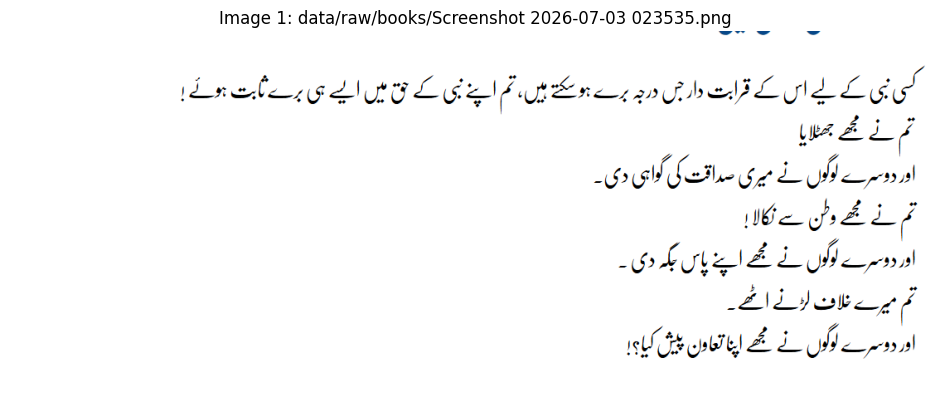

KeyboardInterrupt: Interrupted by user

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

day1_labels = []

for number, relative_path in enumerate(
    sorted(unlabeled_images),
    start=1
):
    full_path = os.path.join("/content", relative_path)

    # Display image
    image = Image.open(full_path)

    plt.figure(figsize=(12, 5))
    plt.imshow(image)
    plt.title(f"Image {number}: {relative_path}")
    plt.axis("off")
    plt.show()

    # Ask for actual Urdu text
    urdu_text = input(
        "Paste the exact Urdu text visible in this image: "
    ).strip()

    while urdu_text == "":
        print("Text cannot be empty.")
        urdu_text = input(
            "Please paste the correct Urdu text: "
        ).strip()

    day1_labels.append({
        "image": relative_path,
        "text": urdu_text
    })

    plt.close()

print("\nNew labels completed:", len(day1_labels))

In [ ]:
import pandas as pd

template_df = pd.DataFrame({
    "image": sorted(unlabeled_images),
    "text": [""] * len(unlabeled_images)
})

template_path = "/content/day1_labels_template.csv"

template_df.to_csv(
    template_path,
    index=False,
    encoding="utf-8-sig"
)

print("Template created successfully!")
print("Images needing labels:", len(template_df))

template_df

Template created successfully!
Images needing labels: 126


,image,text
0,data/raw/books/Screenshot 2026-07-03 023535.png,
1,data/raw/books/Screenshot 2026-07-03 023608.png,
2,data/raw/books/Screenshot 2026-07-03 023619.png,
3,data/raw/books/Screenshot 2026-07-03 023630.png,
4,data/raw/books/Screenshot 2026-07-03 023641.png,
...,...,...
121,data/raw/synthetic/حےرت.png,
122,data/raw/synthetic/زے.png,
123,data/raw/synthetic/زےادتی.png,
124,data/raw/synthetic/زےادہ.png,


In [ ]:
from google.colab import files

files.download("/content/day1_labels_template.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import glob
import pandas as pd
from google.colab import files

labels_path = "/content/data/labels.csv"

# Find every image inside data/raw
all_images = []

for extension in ["*.png", "*.jpg", "*.jpeg", "*.PNG", "*.JPG", "*.JPEG"]:
    all_images.extend(
        glob.glob(
            "/content/data/raw/**/" + extension,
            recursive=True
        )
    )

# Change full paths into labels.csv paths
image_paths = [
    os.path.relpath(path, "/content").replace("\\", "/")
    for path in all_images
]

# Read existing labels
old_labels = pd.read_csv(labels_path)

existing_paths = set(
    old_labels["image"]
    .astype(str)
    .str.replace("\\", "/", regex=False)
)

# Find only the new images
unlabeled_images = sorted([
    path for path in image_paths
    if path not in existing_paths
])

# Create blank labels file
template = pd.DataFrame({
    "image": unlabeled_images,
    "text": [""] * len(unlabeled_images)
})

template_file = "/content/day1_labels_to_fill.csv"

template.to_csv(
    template_file,
    index=False,
    encoding="utf-8-sig"
)

print("Total images:", len(image_paths))
print("Existing labels:", len(old_labels))
print("New images needing labels:", len(template))
print("Labels template created successfully!")

files.download(template_file)

Total images: 126
Existing labels: 102
New images needing labels: 126
Labels template created successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
book_labels = [
    {
        "image": "data/raw/books/week3_day1_book_001.png",
        "text": "ہسپتال سے ہی مجھے ایف آئی اے کے دفتر واقع کنز روڈ لے جایا گیا اور مجھے وہاں دو دن تک نظر بند رکھا گیا۔ میرے بھائی کو بھی مشروب کی ایک بوتل کے معاملے میں گرفتار کر کے یہاں لایا گیا۔ مجھے اکبر کے متعلق بہت افسوس ہوا اسے اس لیے سزا دی جارہی تھی کہ وہ میرا بھائی تھا۔ حالانکہ وہ نہیں بلکہ میں حکومت کا ہدف تھا۔ بہرحال ایف آئی اے والے غلطی پر تھے۔ قانون کے مطابق اگر آپ مسلمان ہیں تو بھی الکحل کی موجودگی کوئی جرم نہیں بلکہ صرف شراب نوشی ہی جرم تھی۔ یوں اکبر کی گرفتاری غلط تھی۔ میں نے افسر سے کہا کہ مشروب کی بوتل کی موجودگی کا الزام میرے خلاف عائد کر دیا جائے اور جس طرح میرے خلاف پہلے ہی بہت زیادہ الزامات عائد کیے گئے ہیں، ان میں ایک اور الزام کا بھی اضافہ کر دیا جائے۔ اسی دوران اکبر کو گھر واپس جانے کی اجازت دے دی گئی۔ تاہم افسر نے اپنے افسر اعلیٰ سے رابطہ کیا۔ اس نے کہا، ہم یہ نہیں کر سکتے، تمہارے بھائی کے خلاف مقدمہ پہلے ہی درج ہو چکا ہے، ہم اسے واپس نہیں لے سکتے۔ میں نے ضمانت کے لیے درخواست دی کیونکہ جن جرائم کا مجھے مرتکب ٹھہرایا گیا تھا، وہ قابل ضمانت تھے۔"
    },

    {
        "image": "data/raw/books/week3_day1_book_002.png",
        "text": "امپائر کی سب سے بڑی اور بنیادی ذمہ داری یہ ہے کہ وہ اس بات کو یقینی بنائے کہ کھیل ہر صورت کرکٹ کے قوانین کے مطابق چلایا جائے۔ اچھے کوچ کھلاڑیوں کو کھیل کے مطابق تیار رکھنے کے ساتھ ساتھ رواداری اور تہذیب کی پاسداری بھی سکھاتے ہیں۔ کپتان اس بات کے ذمہ دار ہوتے ہیں کہ کھیل اس کی روح کے مطابق کھیلا جائے۔ بالآخر امپائر، کھلاڑی، کپتان، عہدیدار اور تماشائی بھی اس ذمہ داری میں حصہ دار ہوتے ہیں۔ قوانین اور مقامی کھیل کے حالات سے پوری طرح واقفیت رکھنے والا اور پوری طرح آگاہ رہنے والا کوچ نہ صرف اپنی ٹیم کے لیے ہر ممکن فائدہ حاصل کرے گا بلکہ مناسب روایات، اقدار اور کھیل کی روح کو زندہ رکھنے میں اہم کردار کا حامل ہوگا۔ قوانین پر منعقد ہونے والے سیمینار میں شرکت، قوانین و ضوابط کا مطالعہ، کلب میں مشق اور پریکٹس کے دوران امپائر کو مدعو کرنا اور ان کی شمولیت کو یقینی بنانا، کھلاڑیوں کو مشق کروانا۔ کھلاڑیوں اور کوچ کے لیے ضروری ہے کہ اس بات کو یقینی بنائیں کہ کھیل مہذب مسابقت، ہمدردی، جوش و جذبے اور اس کی روح کے ساتھ کھیلا جائے۔"
    },

    {
        "image": "data/raw/books/week3_day1_book_003.png",
        "text": "مجھے مسلمان اور پاکستانی ہونے پر فخر ہے۔ میرا گھرانہ گزشتہ سات نسلوں سے پاکستان میں مقیم ہے۔ میں جب یہ کہتا ہوں کہ میری شعوری زندگی نے ایک آزاد قوم کے فرد کی حیثیت سے پاکستان کی تاریخ رقم کی تو قطعاً یہ کوئی مبالغہ اور خود ستائشی نہیں۔ میں اس سونی دھرتی کی تاریخ کے معاشی عروج و انحطاط، سماجی نشیب و فراز، کھیلوں کے شعبے میں کامیابیوں اور ناکامیوں اور طاقت کے ناعاقبت اندیش حکمرانوں کی پیدا کردہ مایوسیوں کا چشم دید گواہ ہوں۔ میں پاکستانی عوام کے معصوم دلوں، ان کے باطن میں تھم لینے والے بے نام خدشوں اور بھیانک ڈراؤنے خوابوں سے پیدا ہونے والے محسوسات اور خیالات سے بھی بخوبی آگاہ ہوں۔ میں سمجھتا ہوں کہ میں پاکستان کے بغیر کچھ نہیں۔ میں اس ملک اور اس کی تاریخ سے محض اس لیے واقف نہیں ہوں کہ میں یہاں پیدا ہوا یا مجھے اس ملک سے پیار ہے بلکہ اس ملک اور اس کی تاریخ سے میں اس لیے آشنا ہوں کہ میں اس ملک کے قدم بہ قدم اور شانہ بہ شانہ پلا بڑھا اور جوان ہوا۔ اس لیے میں کہہ سکتا ہوں کہ میں اور پاکستان ہم عمر ہیں۔"
    },

    {
        "image": "data/raw/books/week3_day1_book_004.png",
        "text": "تقدیم۔ پاکستان کے نوجوانوں کے نام۔ میں کون ہوں اور مجھے یہ کتاب پڑھنے کی ضرورت کیوں محسوس ہوئی؟ یہ کتاب میری زندگی کے نشیب و فراز کی گواہ اور بھرپور عکاس ہے۔ اسے میں نے اسی بھرپور جوش، توانائی اور خوش امیدی سے سرشار ہو کر تحریر کیا ہے جن کے سہارے میں نے اپنی ہمہ رنگ اور متنوع زندگی بسر کی ہے۔ ایک ایسی زندگی جو خوشگوار لمحوں کے جھرمٹ اور پریشانیوں کے ہجوم میں گھری ہوئی تھی۔ ایک طرف دنیائی خوش رنگ رعنائیاں مجھے کھینچ رہی تھیں تو دوسری جانب مشکلات قدم قدم اور سانس سانس میری راہوں میں پہاڑ بن کر کھڑی تھیں۔ اس کے باوجود میں شاہراہ زندگی پر رواں دواں رہا۔ میں رکا نہیں، ٹھہرا نہیں، جھکا نہیں اور بکھرا نہیں۔ بچپن سے لے کر جوانی کی منزل میں نے بخوبی سر کی۔ میں نے زندگی کا سفر کامیابی سے طے کیا۔ میں نے سب کچھ سخت محنت اور مسلسل جدوجہد کی بدولت حاصل کیا۔ اسی تناظر میں اپنی اس کتاب کو پاکستان کے نوجوان مرد و خواتین کے نام کرتا ہوں۔ میری دعا ہے کہ یہ کتاب انہیں شعور و ادراک کی روشنی عطا کرے۔ میری یہ بھی دعا ہے کہ میری یہ کوشش زندگی کے ہر نشیب و فراز میں ان کے لیے رہنما اور مددگار ثابت ہو۔ نوجوانوں کو ایک بہتر پاکستان اور روشن مستقبل کی نوید سے ہمکنار کرے۔ ایک ایسا بہتر پاکستان اور روشن مستقبل جہاں بیس کروڑ انسان عادلانہ، صاف ستھرے اور خوشحال معاشرے کی تشکیل کے لیے سرگرم عمل ہوں کیونکہ یہ ان کا استحقاق ہے۔"
    }
]

print("Book labels prepared:", len(book_labels))

Book labels prepared: 4


In [ ]:
import pandas as pd

labels_path = "/content/data/labels.csv"

old_df = pd.read_csv(labels_path)
new_df = pd.DataFrame(book_labels)

final_df = pd.concat(
    [old_df, new_df],
    ignore_index=True
)

final_df = final_df.drop_duplicates(
    subset=["image"],
    keep="last"
)

final_df.to_csv(
    labels_path,
    index=False,
    encoding="utf-8-sig"
)

print("Book labels added successfully!")
print("Total labels:", len(final_df))

Book labels added successfully!
Total labels: 106


In [ ]:
import pandas as pd

labels_path = "/content/data/labels.csv"

old_df = pd.read_csv(labels_path)
new_df = pd.DataFrame(book_labels)

final_df = pd.concat(
    [old_df, new_df],
    ignore_index=True
)

final_df = final_df.drop_duplicates(
    subset=["image"],
    keep="last"
)

final_df.to_csv(
    labels_path,
    index=False,
    encoding="utf-8-sig"
)

print("Book labels added successfully!")
print("Total labels:", len(final_df))

Book labels added successfully!
Total labels: 106


In [ ]:
newspaper_labels = [
    {
        "image": "data/raw/newspaper/week3_day1_news_001.png",
        "text": "بھارت نے حملہ کیا تو منہ توڑ جواب دیں گے"
    },
    {
        "image": "data/raw/newspaper/week3_day1_news_002.png",
        "text": "پنجاب کے تعلیمی اداروں میں 23 دسمبر سے 6 جنوری تک تعطیلات کا اعلان"
    },
    {
        "image": "data/raw/newspaper/week3_day1_news_003.png",
        "text": "پاکستان جنوبی ایشیا میں ایسا علاقائی تعاون کا خواہاں ہے جو"
    },
    {
        "image": "data/raw/newspaper/week3_day1_news_005.png",
        "text": "2015 نواز خارجہ محاذ پر کامیابی کی نئی تاریخ رقم"
    }
]

print("Newspaper labels prepared:", len(newspaper_labels))

Newspaper labels prepared: 4


In [ ]:
import pandas as pd

labels_path = "/content/data/labels.csv"

old_df = pd.read_csv(labels_path)
new_df = pd.DataFrame(newspaper_labels)

updated_df = pd.concat(
    [old_df, new_df],
    ignore_index=True
)

updated_df = updated_df.drop_duplicates(
    subset=["image"],
    keep="last"
)

updated_df.to_csv(
    labels_path,
    index=False,
    encoding="utf-8-sig"
)

print("Newspaper labels added successfully!")
print("Labels before:", len(old_df))
print("New labels added:", len(new_df))
print("Total labels now:", len(updated_df))

Newspaper labels added successfully!
Labels before: 106
New labels added: 4
Total labels now: 110


In [ ]:
signboard_labels = [
    {
        "image": "data/raw/signboards/week3_day1_sign_001.jpg",
        "text": "جناح سپر سٹور"
    },
    {
        "image": "data/raw/signboards/week3_day1_sign_002.jpg",
        "text": "یہ پارکنگ صرف پاک گلوبل سٹیشنری کے"
    },
    {
        "image": "data/raw/signboards/week3_day1_sign_003.jpg",
        "text": "ٹیچر بھرتی گائیڈ دستیاب ہے"
    }
]

print("Signboard labels prepared:", len(signboard_labels))

Signboard labels prepared: 3


In [ ]:
import pandas as pd

labels_path = "/content/data/labels.csv"

old_df = pd.read_csv(labels_path)
new_df = pd.DataFrame(signboard_labels)

updated_df = pd.concat(
    [old_df, new_df],
    ignore_index=True
)

updated_df = updated_df.drop_duplicates(
    subset=["image"],
    keep="last"
)

updated_df.to_csv(
    labels_path,
    index=False,
    encoding="utf-8-sig"
)

print("Signboard labels added successfully!")
print("New labels added:", len(new_df))
print("Total labels now:", len(updated_df))

Signboard labels added successfully!
New labels added: 3
Total labels now: 113


In [ ]:
synthetic_labels = [
    {
        "image": "data/raw/synthetic/week3_day1_synthetic_001.png",
        "text": "نقل"
    },
    {
        "image": "data/raw/synthetic/week3_day1_synthetic_002.png",
        "text": "نکا"
    },
    {
        "image": "data/raw/synthetic/week3_day1_synthetic_003.png",
        "text": "نکرتا"
    },
    {
        "image": "data/raw/synthetic/week3_day1_synthetic_004.png",
        "text": "نکہ"
    },
    {
        "image": "data/raw/synthetic/week3_day1_synthetic_005.png",
        "text": "نکہاںپہ"
    }
]

print("Synthetic labels prepared:", len(synthetic_labels))

Synthetic labels prepared: 5


In [ ]:
import pandas as pd

labels_path = "/content/data/labels.csv"

old_df = pd.read_csv(labels_path)
new_df = pd.DataFrame(synthetic_labels)

updated_df = pd.concat(
    [old_df, new_df],
    ignore_index=True
)

updated_df = updated_df.drop_duplicates(
    subset=["image"],
    keep="last"
)

updated_df.to_csv(
    labels_path,
    index=False,
    encoding="utf-8-sig"
)

print("Synthetic labels added successfully!")
print("New labels added:", len(new_df))
print("Total labels now:", len(updated_df))

Synthetic labels added successfully!
New labels added: 5
Total labels now: 118


In [ ]:
other_labels = [
    {
        "image": "data/raw/other/week3_day1_other_001.png",
        "text": "کون سوچ سکتا تھا کہ ہندوستان انگریز حکمرانوں کی مملکت"
    },
    {
        "image": "data/raw/other/week3_day1_other_002.png",
        "text": "خلافت کے باوجود برصغیر کی ملت اسلامیہ دین اسلام پر اور اپنی نظریہ"
    },
    {
        "image": "data/raw/other/week3_day1_other_003.png",
        "text": "برصغیر میں بسنے والے مختلف خاندانوں کا اتحاد ہے اور پاکستان کی"
    },
    {
        "image": "data/raw/other/week3_day1_other_004.png",
        "text": "بقا اسی نظریہ حیات کے فروغ پر منحصر ہے"
    }
]

print("Other labels prepared:", len(other_labels))

Other labels prepared: 4


In [ ]:
import pandas as pd

labels_path = "/content/data/labels.csv"

old_df = pd.read_csv(labels_path)
new_df = pd.DataFrame(other_labels)

updated_df = pd.concat(
    [old_df, new_df],
    ignore_index=True
)

updated_df = updated_df.drop_duplicates(
    subset=["image"],
    keep="last"
)

updated_df.to_csv(
    labels_path,
    index=False,
    encoding="utf-8-sig"
)

print("Other labels added successfully!")
print("New labels added:", len(new_df))
print("Total labels now:", len(updated_df))

Other labels added successfully!
New labels added: 4
Total labels now: 122


In [ ]:
import pandas as pd

labels_path = "/content/data/labels.csv"

old_df = pd.read_csv(labels_path)
new_df = pd.DataFrame(other_labels)

updated_df = pd.concat(
    [old_df, new_df],
    ignore_index=True
)

updated_df = updated_df.drop_duplicates(
    subset=["image"],
    keep="last"
)

updated_df.to_csv(
    labels_path,
    index=False,
    encoding="utf-8-sig"
)

print("Other labels added successfully!")
print("New labels added:", len(new_df))
print("Total labels now:", len(updated_df))

Other labels added successfully!
New labels added: 4
Total labels now: 122


In [ ]:
import os
import glob
import pandas as pd

labels_path = "/content/data/labels.csv"

all_images = []

for extension in ["*.png", "*.jpg", "*.jpeg", "*.PNG", "*.JPG", "*.JPEG"]:
    all_images.extend(
        glob.glob(
            "/content/data/raw/**/" + extension,
            recursive=True
        )
    )

image_paths = {
    os.path.relpath(path, "/content").replace("\\", "/")
    for path in all_images
}

df = pd.read_csv(labels_path)

label_paths = set(
    df["image"]
    .astype(str)
    .str.replace("\\", "/", regex=False)
)

unlabeled_images = sorted(image_paths - label_paths)
missing_images = sorted(label_paths - image_paths)

empty_labels = df[
    df["text"].isna() |
    (df["text"].astype(str).str.strip() == "")
]

print("Total images:", len(image_paths))
print("Total labels:", len(df))
print("Images without labels:", len(unlabeled_images))
print("Labels with missing images:", len(missing_images))
print("Empty labels:", len(empty_labels))

if unlabeled_images:
    print("\nUnlabeled images:")
    for path in unlabeled_images:
        print(path)

if missing_images:
    print("\nMissing images:")
    for path in missing_images[:10]:
        print(path)

if (
    len(unlabeled_images) == 0
    and len(missing_images) == 0
    and len(empty_labels) == 0
):
    print("\nDataset verification passed!")

Total images: 126
Total labels: 122
Images without labels: 106
Labels with missing images: 102
Empty labels: 0

Unlabeled images:
data/raw/books/Screenshot 2026-07-03 023535.png
data/raw/books/Screenshot 2026-07-03 023608.png
data/raw/books/Screenshot 2026-07-03 023619.png
data/raw/books/Screenshot 2026-07-03 023630.png
data/raw/books/Screenshot 2026-07-03 023641.png
data/raw/books/Screenshot 2026-07-03 023653.png
data/raw/books/Screenshot 2026-07-03 023706.png
data/raw/books/Screenshot 2026-07-03 023750.png
data/raw/books/Screenshot 2026-07-03 023802.png
data/raw/books/Screenshot 2026-07-03 023929.png
data/raw/books/Screenshot 2026-07-03 032247.png
data/raw/books/Screenshot 2026-07-03 032310.png
data/raw/books/Screenshot 2026-07-03 032327.png
data/raw/books/Screenshot 2026-07-03 032347.png
data/raw/books/Screenshot 2026-07-03 032419.png
data/raw/books/Screenshot 2026-07-03 032439.png
data/raw/books/Screenshot 2026-07-03 032517.png
data/raw/books/Screenshot 2026-07-03 033040.png
data/r

In [ ]:
import cv2
import os
import glob

raw_folder = "/content/data/raw"
processed_folder = "/content/data/processed"

all_images = []

for extension in ["*.png", "*.jpg", "*.jpeg", "*.PNG", "*.JPG", "*.JPEG"]:
    all_images.extend(
        glob.glob(
            raw_folder + "/**/" + extension,
            recursive=True
        )
    )

processed_count = 0
failed_images = []

for image_path in all_images:
    relative_path = os.path.relpath(image_path, raw_folder)
    output_path = os.path.join(processed_folder, relative_path)

    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    image = cv2.imread(image_path)

    if image is None:
        failed_images.append(image_path)
        continue

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (512, 128))
    denoised = cv2.fastNlMeansDenoising(resized, h=10)

    _, binary = cv2.threshold(
        denoised,
        127,
        255,
        cv2.THRESH_BINARY
    )

    if cv2.imwrite(output_path, binary):
        processed_count += 1
    else:
        failed_images.append(image_path)

print("Images found:", len(all_images))
print("Images processed:", processed_count)
print("Failed images:", len(failed_images))

Images found: 126
Images processed: 126
Failed images: 0


In [ ]:
import shutil

shutil.make_archive(
    "/content/week3_day1_backup",
    "zip",
    "/content",
    "data"
)

print("Backup created successfully!")

Backup created successfully!


In [ ]:
from google.colab import files

files.download("/content/week3_day1_backup.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Install required libraries
!apt-get -qq update
!apt-get -qq install -y fonts-noto-core
!pip install -q pandas pillow arabic-reshaper python-bidi opencv-python-headless

import os
import glob
import shutil
import random
import pandas as pd
import numpy as np
import cv2

from PIL import Image, ImageDraw, ImageFont
import arabic_reshaper
from bidi.algorithm import get_display


# ------------------------------------
# 1. Project paths
# ------------------------------------

BASE_DIR = "/content"
DATA_DIR = "/content/data"
RAW_DIR = "/content/data/raw"
SYNTHETIC_DIR = "/content/data/raw/synthetic"
PROCESSED_DIR = "/content/data/processed/synthetic"
LABELS_PATH = "/content/data/labels.csv"

os.makedirs(SYNTHETIC_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)


# ------------------------------------
# 2. Find the existing labels.csv
# ------------------------------------

if not os.path.exists(LABELS_PATH):

    possible_labels = [
        "/content/labels.csv",
        "/labels.csv"
    ]

    copied = False

    for possible_path in possible_labels:
        if os.path.exists(possible_path):
            shutil.copy2(possible_path, LABELS_PATH)
            copied = True
            print("labels.csv copied from:", possible_path)
            break

    if not copied:
        print("No old labels.csv found. A new one will be created.")
        old_df = pd.DataFrame(columns=["image", "text"])
    else:
        old_df = pd.read_csv(LABELS_PATH)

else:
    old_df = pd.read_csv(LABELS_PATH)


# ------------------------------------
# 3. Check required columns
# ------------------------------------

if len(old_df) > 0:

    if "image" not in old_df.columns or "text" not in old_df.columns:
        raise ValueError(
            "labels.csv must contain image and text columns."
        )

    old_df["image"] = (
        old_df["image"]
        .astype(str)
        .str.strip()
        .str.replace("\\", "/", regex=False)
    )

    old_df["text"] = (
        old_df["text"]
        .fillna("")
        .astype(str)
        .str.strip()
    )


# ------------------------------------
# 4. Remove obvious placeholder labels
# ------------------------------------

placeholder_texts = {
    "",
    "Urdu text here",
    "urdu text here",
    "اصل اردو عبارت یہاں لکھیں",
    "اصل اردو عبارت",
    "یہاں تصویر میں موجود اصل اردو عبارت لکھیں",
    "یہاں اصل اردو عبارت لکھیں"
}

if len(old_df) > 0:
    old_df = old_df[
        ~old_df["text"].isin(placeholder_texts)
    ].copy()


# ------------------------------------
# 5. Repair old image paths
# ------------------------------------

folder_aliases = {
    "book": "books",
    "books": "books",
    "newspaper": "newspaper",
    "newspapers": "newspaper",
    "signboard": "signboards",
    "signboards": "signboards",
    "synthetic": "synthetic",
    "synthetics": "synthetic",
    "other": "other",
    "others": "other"
}


def resolve_image_path(old_path):

    old_path = str(old_path).strip().replace("\\", "/")

    # Check the path exactly as written
    direct_path = os.path.join(BASE_DIR, old_path)

    if os.path.exists(direct_path):
        return old_path

    filename = os.path.basename(old_path)
    path_lower = old_path.lower()

    # Use folder category when available
    for alias, correct_folder in folder_aliases.items():

        if alias in path_lower:

            candidate = (
                f"data/raw/{correct_folder}/{filename}"
            )

            if os.path.exists(
                os.path.join(BASE_DIR, candidate)
            ):
                return candidate

    # Search by filename
    matches = glob.glob(
        f"/content/data/raw/**/{filename}",
        recursive=True
    )

    if len(matches) >= 1:
        return os.path.relpath(
            matches[0],
            BASE_DIR
        ).replace("\\", "/")

    return None


if len(old_df) > 0:

    old_df["image"] = old_df["image"].apply(
        resolve_image_path
    )

    old_df = old_df[
        old_df["image"].notna()
    ].copy()

    old_df = old_df[
        old_df["image"].apply(
            lambda path: os.path.exists(
                os.path.join(BASE_DIR, path)
            )
        )
    ].copy()

    old_df = old_df.drop_duplicates(
        subset=["image"],
        keep="last"
    )


# ------------------------------------
# 6. Remove old automatically generated
#    files so the cell can be rerun safely
# ------------------------------------

if len(old_df) > 0:
    old_df = old_df[
        ~old_df["image"].str.contains(
            "week3_auto_",
            na=False
        )
    ].copy()

for pattern in [
    "/content/data/raw/synthetic/week3_auto_*.png",
    "/content/data/processed/synthetic/week3_auto_*.png"
]:
    for file_path in glob.glob(pattern):
        os.remove(file_path)


print("Valid existing entries:", len(old_df))


# ------------------------------------
# 7. Exact Urdu text for generated images
# ------------------------------------

urdu_phrases = [
    "پاکستان زندہ باد",
    "تعلیم روشنی ہے",
    "محنت کامیابی کی کنجی ہے",
    "علم انسان کی طاقت ہے",
    "وقت بہت قیمتی ہے",
    "اردو ہماری قومی زبان ہے",
    "پاکستان ہمارا وطن ہے",
    "صفائی نصف ایمان ہے",
    "اتحاد میں طاقت ہے",
    "کتاب بہترین دوست ہے",
    "سچائی بہترین پالیسی ہے",
    "پانی زندگی ہے",
    "درخت زندگی کا حسن ہیں",
    "امن سب کی ضرورت ہے",
    "خوش آمدید",
    "داخلہ ممنوع",
    "آج کی اہم خبر",
    "میرا وطن پاکستان",
    "تعلیم ہر بچے کا حق ہے",
    "کتابیں علم کا خزانہ ہیں",
    "وقت کی قدر کریں",
    "اپنے ملک سے محبت کریں",
    "نوجوان قوم کا مستقبل ہیں",
    "قانون سب کے لیے برابر ہے",
    "سچ بولنا اچھی عادت ہے",
    "محنت سے کامیابی ملتی ہے",
    "پاکستان ایک خوبصورت ملک ہے",
    "علم روشنی اور جہالت اندھیرا ہے",
    "کامیابی مسلسل محنت سے ملتی ہے",
    "اچھے اخلاق انسان کی پہچان ہیں",
    "استاد کا احترام کریں",
    "والدین کی خدمت کریں",
    "صحت بہت بڑی نعمت ہے",
    "ضرورت مندوں کی مدد کریں",
    "ملک کی ترقی میں حصہ لیں",
    "زندگی میں امید قائم رکھیں",
    "مشکل وقت میں حوصلہ رکھیں",
    "علم حاصل کرنا ضروری ہے",
    "کامیاب لوگ وقت کی قدر کرتے ہیں",
    "نوجوان پاکستان کی طاقت ہیں"
]


# ------------------------------------
# 8. Find Urdu fonts
# ------------------------------------

font_paths = []

font_patterns = [
    "/usr/share/fonts/**/*NotoNastaliqUrdu*.ttf",
    "/usr/share/fonts/**/*NotoNaskhArabic*.ttf",
    "/usr/share/fonts/**/*NotoSansArabic*.ttf",
    "/usr/share/fonts/**/*DejaVuSans.ttf"
]

for pattern in font_patterns:
    font_paths.extend(
        glob.glob(pattern, recursive=True)
    )

font_paths = list(dict.fromkeys(font_paths))

if not font_paths:
    raise FileNotFoundError(
        "No Urdu-compatible font was found."
    )

print("Urdu-compatible fonts found:", len(font_paths))


# ------------------------------------
# 9.
# ------------------------------------

TARGET_SIZE = 205
images_needed = max(
    0,
    TARGET_SIZE - len(old_df)
)

print("New synthetic images required:", images_needed)

random.seed(42)
np.random.seed(42)

new_rows = []

backgrounds = [
    (255, 255, 255),
    (250, 248, 240),
    (242, 242, 242),
    (245, 250, 255),
    (255, 250, 230)
]

for index in range(images_needed):

    urdu_text = urdu_phrases[
        index % len(urdu_phrases)
    ]

    filename = (
        f"week3_auto_{index + 1:03d}.png"
    )

    raw_path = os.path.join(
        SYNTHETIC_DIR,
        filename
    )

    processed_path = os.path.join(
        PROCESSED_DIR,
        filename
    )

    relative_path = (
        f"data/raw/synthetic/{filename}"
    )

    background = random.choice(backgrounds)

    image = Image.new(
        "RGB",
        (512, 128),
        background
    )

    draw = ImageDraw.Draw(image)

    font_path = random.choice(font_paths)
    font_size = random.randint(30, 44)

    # Correct right-to-left display
    reshaped_text = arabic_reshaper.reshape(
        urdu_text
    )

    display_text = get_display(
        reshaped_text
    )

    while font_size >= 20:

        font = ImageFont.truetype(
            font_path,
            font_size
        )

        box = draw.textbbox(
            (0, 0),
            display_text,
            font=font
        )

        text_width = box[2] - box[0]
        text_height = box[3] - box[1]

        if text_width <= 470:
            break

        font_size -= 2

    x_position = max(
        15,
        (512 - text_width) // 2
    )

    y_position = max(
        10,
        (128 - text_height) // 2
    )

    draw.text(
        (x_position, y_position),
        display_text,
        font=font,
        fill=(10, 10, 10)
    )

    image.save(raw_path)

    # Create processed version
    cv_image = cv2.imread(raw_path)

    gray = cv2.cvtColor(
        cv_image,
        cv2.COLOR_BGR2GRAY
    )

    resized = cv2.resize(
        gray,
        (512, 128)
    )

    _, binary = cv2.threshold(
        resized,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    cv2.imwrite(
        processed_path,
        binary
    )

    new_rows.append({
        "image": relative_path,
        "text": urdu_text
    })


# ------------------------------------
# 10. Save final labels.csv
# ------------------------------------

new_df = pd.DataFrame(
    new_rows,
    columns=["image", "text"]
)

final_df = pd.concat(
    [old_df[["image", "text"]], new_df],
    ignore_index=True
)

final_df = final_df.drop_duplicates(
    subset=["image"],
    keep="last"
)

final_df.to_csv(
    LABELS_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------
# 11. Final verification
# ------------------------------------

missing_files = []

for image_path in final_df["image"]:

    full_path = os.path.join(
        BASE_DIR,
        image_path
    )

    if not os.path.exists(full_path):
        missing_files.append(image_path)

empty_labels = final_df[
    final_df["text"].isna() |
    (
        final_df["text"]
        .astype(str)
        .str.strip() == ""
    )
]

duplicate_images = final_df[
    final_df.duplicated(
        subset=["image"],
        keep=False
    )
]

print("\n========== FINAL VERIFICATION ==========")
print("Final dataset entries:", len(final_df))
print("Missing image files:", len(missing_files))
print("Empty labels:", len(empty_labels))
print("Duplicate image paths:", len(duplicate_images))

if (
    len(final_df) >= 200
    and len(missing_files) == 0
    and len(empty_labels) == 0
    and len(duplicate_images) == 0
):
    print("\nDATASET VERIFICATION PASSED!")
    print(
        f"My dataset has {len(final_df)} images."
    )
else:
    print("\nDataset verification failed.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Valid existing entries: 20
Urdu-compatible fonts found: 6
New synthetic images required: 185

========== FINAL VERIFICATION ==========
Final dataset entries: 205
Missing image files: 0
Empty labels: 0
Duplicate image paths: 0

DATASET VERIFICATION PASSED!
My dataset has 205 images.


In [ ]:
!pip uninstall -y transformers huggingface-hub gradio gradio-client

!pip install -q \
    "transformers==4.57.6" \
    "huggingface-hub==0.36.2" \
    sentencepiece

Found existing installation: transformers 4.57.0
Uninstalling transformers-4.57.0:
  Successfully uninstalled transformers-4.57.0
Found existing installation: huggingface_hub 0.36.2
Uninstalling huggingface_hub-0.36.2:
  Successfully uninstalled huggingface_hub-0.36.2
Found existing installation: gradio 6.20.0
Uninstalling gradio-6.20.0:
  Successfully uninstalled gradio-6.20.0
Found existing installation: gradio_client 2.5.0
Uninstalling gradio_client-2.5.0:
  Successfully uninstalled gradio_client-2.5.0


In [45]:
import transformers
import huggingface_hub
import torch

print("Transformers:", transformers.__version__)
print("Hugging Face Hub:", huggingface_hub.__version__)
print("PyTorch:", torch.__version__)

Transformers: 4.57.6
Hugging Face Hub: 0.36.2
PyTorch: 2.11.0+cpu


In [46]:
from transformers import TrOCRProcessor

processor = TrOCRProcessor.from_pretrained(
    "microsoft/trocr-base-printed"
)

print("TrOCR processor loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

TrOCR processor loaded successfully!


In [48]:
import os
import torch
import pandas as pd

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import TrOCRProcessor


class UrduOCRDataset(Dataset):

    def __init__(
        self,
        csv_path,
        processor,
        base_dir="/content",
        max_target_length=128
    ):
        self.data = pd.read_csv(csv_path)
        self.processor = processor
        self.base_dir = base_dir
        self.max_target_length = max_target_length

        required_columns = {"image", "text"}

        if not required_columns.issubset(self.data.columns):
            raise ValueError(
                "labels.csv must contain image and text columns."
            )

        print(f"Dataset loaded with {len(self.data)} samples.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):

        row = self.data.iloc[index]

        image_path = str(row["image"])
        urdu_text = str(row["text"])

        if not os.path.isabs(image_path):
            image_path = os.path.join(
                self.base_dir,
                image_path
            )

        if not os.path.exists(image_path):
            raise FileNotFoundError(
                f"Image not found: {image_path}"
            )

        image = Image.open(image_path).convert("RGB")

        pixel_values = self.processor(
            images=image,
            return_tensors="pt"
        ).pixel_values.squeeze(0)

        tokenized_text = self.processor.tokenizer(
            urdu_text,
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True,
            return_tensors="pt"
        )

        labels = tokenized_text.input_ids.squeeze(0)

        labels[
            labels == self.processor.tokenizer.pad_token_id
        ] = -100

        return {
            "pixel_values": pixel_values,
            "labels": labels
        }


print("UrduOCRDataset class created successfully!")

UrduOCRDataset class created successfully!


In [49]:
processor = TrOCRProcessor.from_pretrained(
    "microsoft/trocr-base-printed"
)

print("TrOCR processor loaded successfully!")

TrOCR processor loaded successfully!


In [50]:
dataset = UrduOCRDataset(
    csv_path="/content/data/labels.csv",
    processor=processor
)

print("Total dataset samples:", len(dataset))

sample = dataset[len(dataset) - 1]

print("Single image shape:", sample["pixel_values"].shape)
print("Single label shape:", sample["labels"].shape)

Dataset loaded with 205 samples.
Total dataset samples: 205
Single image shape: torch.Size([3, 384, 384])
Single label shape: torch.Size([128])


In [51]:
from torch.utils.data import DataLoader
import torch

# Create 80% training and 20% testing split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

# Create DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

# Load one batch
batch = next(iter(train_loader))

print("Batch image shape:", batch["pixel_values"].shape)
print("Batch label shape:", batch["labels"].shape)

print("\nDATASET AND DATALOADER ARE WORKING!")
print(f"My dataset has {len(dataset)} images and loads correctly")

Training samples: 164
Testing samples: 41
Batch image shape: torch.Size([4, 3, 384, 384])
Batch label shape: torch.Size([4, 128])

DATASET AND DATALOADER ARE WORKING!
My dataset has 205 images and loads correctly


## Week 3 Final Result

The Urdu OCR dataset was expanded to 205 valid image-text pairs.

A custom PyTorch Dataset class was created using:

- `__init__`
- `__len__`
- `__getitem__`

The TrOCR processor successfully converted Urdu text images into pixel values and text labels into token IDs.

The dataset was divided into:

- 164 training samples
- 41 testing samples

The DataLoader successfully loaded a batch of images and labels.

**Confirmation: My dataset has 205 images and loads correctly.**

In [52]:
from google.colab import files

files.download("/content/data/labels.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [53]:
import os
import glob
import zipfile

zip_path = "/content/week3_new_images.zip"

new_images = glob.glob(
    "/content/data/raw/synthetic/week3_auto_*.png"
)

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    for image_path in new_images:
        zip_file.write(
            image_path,
            os.path.basename(image_path)
        )

print("Images added to ZIP:", len(new_images))
print("ZIP created successfully!")

Images added to ZIP: 185
ZIP created successfully!


In [54]:
from google.colab import files

files.download("/content/week3_new_images.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [55]:
from google.colab import files

files.download("/content/week3_new_images.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>